In [10]:
import numpy as np
import pandas as pd
import random
from sklearn.datasets import make_classification

In [2]:
x,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)

In [5]:
df = pd.DataFrame(x,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.sample(5)

(100, 6)


,col1,col2,col3,col4,col5,target
73,0.001334,-0.982236,-0.103505,-0.604266,0.248184,0
68,1.510935,-0.832060,1.126595,2.171405,2.113977,1
23,0.135278,-1.693238,1.674821,-0.224963,-1.827569,0
60,0.865419,1.951522,3.010730,2.254995,1.994079,1
31,0.080032,-2.896343,2.418140,-2.848046,-3.123058,0


In [6]:
# function for row sampling

def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]),replace=True)

In [11]:
# function for feature sampling
def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols]
  new_df['target'] = df['target']
  return new_df

In [12]:
# function for combined sampling

def combined_sampling(df,row_percent,col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

In [13]:
df1 = combined_sampling(df,0.5,0.5)

C:\Users\Shubham\AppData\Local\Temp\ipykernel_9696\3275485051.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [14]:
df2 = combined_sampling(df,0.5,0.5)

C:\Users\Shubham\AppData\Local\Temp\ipykernel_9696\3275485051.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [15]:
df3 = combined_sampling(df,0.5,0.5)

C:\Users\Shubham\AppData\Local\Temp\ipykernel_9696\3275485051.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [16]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col1', 'col2', 'target'], dtype='object')
Index(['col4', 'col3', 'target'], dtype='object')
Index(['col4', 'col1', 'target'], dtype='object')


In [17]:
df3

,col4,col1,target
9,-2.040035,1.280256,0
7,-1.024833,-0.128803,0
11,1.533075,4.026253,1
56,-3.221036,0.792216,0
25,0.581179,0.893159,1
82,1.123313,0.548133,1
85,2.053299,0.609812,0
5,-1.136751,0.879534,0
26,0.773789,2.097448,1
45,0.856336,0.406535,0


In [18]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [19]:
clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [20]:
from sklearn.tree import plot_tree

[Text(0.38333333333333336, 0.9375, 'x[1] <= -1.7\ngini = 0.499\nsamples = 50\nvalue = [26, 24]'),
 Text(0.2, 0.8125, 'x[0] <= 0.496\ngini = 0.231\nsamples = 15\nvalue = [2, 13]'),
 Text(0.2916666666666667, 0.875, 'True  '),
 Text(0.13333333333333333, 0.6875, 'x[0] <= -0.108\ngini = 0.408\nsamples = 7\nvalue = [2, 5]'),
 Text(0.06666666666666667, 0.5625, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.2, 0.5625, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.26666666666666666, 0.6875, 'gini = 0.0\nsamples = 8\nvalue = [0, 8]'),
 Text(0.5666666666666667, 0.8125, 'x[0] <= -0.017\ngini = 0.431\nsamples = 35\nvalue = [24, 11]'),
 Text(0.475, 0.875, '  False'),
 Text(0.4, 0.6875, 'x[1] <= -1.354\ngini = 0.278\nsamples = 6\nvalue = [1, 5]'),
 Text(0.3333333333333333, 0.5625, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.4666666666666667, 0.5625, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.7333333333333333, 0.6875, 'x[1] <= -0.066\ngini = 0.328\nsamples = 29\nvalue = [23

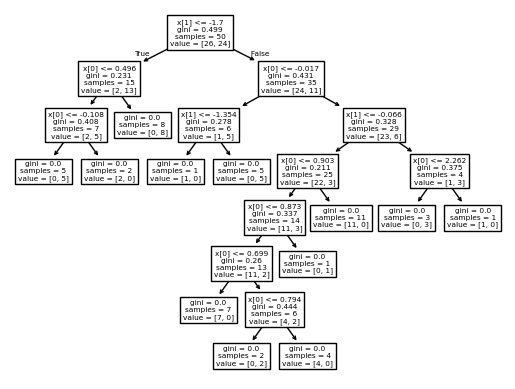

In [21]:
plot_tree(clf1)

[Text(0.5, 0.9166666666666666, 'x[0] <= -0.069\ngini = 0.499\nsamples = 50\nvalue = [26, 24]'),
 Text(0.2, 0.75, 'x[1] <= 1.068\ngini = 0.083\nsamples = 23\nvalue = [22, 1]'),
 Text(0.35, 0.8333333333333333, 'True  '),
 Text(0.1, 0.5833333333333334, 'gini = 0.0\nsamples = 17\nvalue = [17, 0]'),
 Text(0.3, 0.5833333333333334, 'x[1] <= 1.351\ngini = 0.278\nsamples = 6\nvalue = [5, 1]'),
 Text(0.2, 0.4166666666666667, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.4, 0.4166666666666667, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.8, 0.75, 'x[0] <= 1.158\ngini = 0.252\nsamples = 27\nvalue = [4, 23]'),
 Text(0.65, 0.8333333333333333, '  False'),
 Text(0.7, 0.5833333333333334, 'x[0] <= 0.497\ngini = 0.463\nsamples = 11\nvalue = [4, 7]'),
 Text(0.6, 0.4166666666666667, 'gini = 0.0\nsamples = 6\nvalue = [0, 6]'),
 Text(0.8, 0.4166666666666667, 'x[1] <= 0.291\ngini = 0.32\nsamples = 5\nvalue = [4, 1]'),
 Text(0.7, 0.25, 'x[0] <= 0.836\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Te

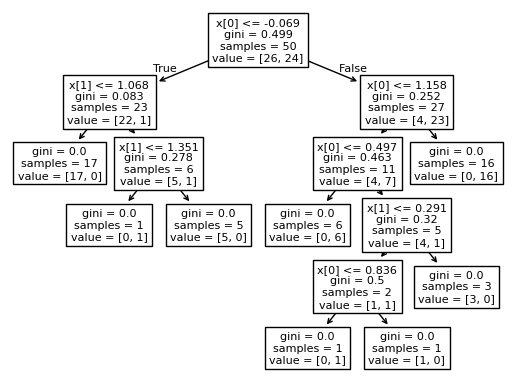

In [22]:
plot_tree(clf2)

[Text(0.4230769230769231, 0.9375, 'x[0] <= -0.037\ngini = 0.499\nsamples = 50\nvalue = [24, 26]'),
 Text(0.15384615384615385, 0.8125, 'x[1] <= 0.588\ngini = 0.172\nsamples = 21\nvalue = [19, 2]'),
 Text(0.28846153846153844, 0.875, 'True  '),
 Text(0.07692307692307693, 0.6875, 'gini = 0.0\nsamples = 9\nvalue = [9, 0]'),
 Text(0.23076923076923078, 0.6875, 'x[1] <= 0.776\ngini = 0.278\nsamples = 12\nvalue = [10, 2]'),
 Text(0.15384615384615385, 0.5625, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.3076923076923077, 0.5625, 'x[1] <= 1.505\ngini = 0.165\nsamples = 11\nvalue = [10, 1]'),
 Text(0.23076923076923078, 0.4375, 'gini = 0.0\nsamples = 7\nvalue = [7, 0]'),
 Text(0.38461538461538464, 0.4375, 'x[1] <= 2.046\ngini = 0.375\nsamples = 4\nvalue = [3, 1]'),
 Text(0.3076923076923077, 0.3125, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.46153846153846156, 0.3125, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.6923076923076923, 0.8125, 'x[1] <= 0.477\ngini = 0.285\nsamples =

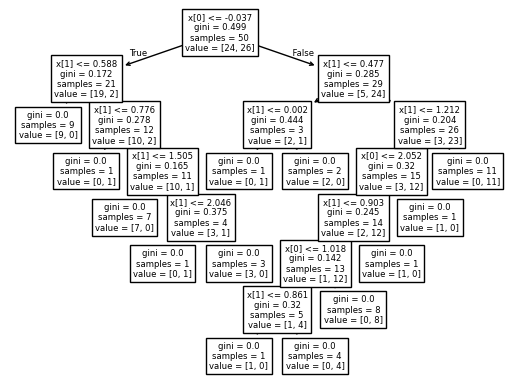

In [23]:
plot_tree(clf3)

In [24]:
# Lets see the Outputs of all models and use the aggreation Techiques 

In [29]:
clf1.predict(np.array([-0.659783 , 0.537666]).reshape(1,2))

D:\anaconda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [30]:
clf2.predict(np.array([-0.659783 , 0.537666]).reshape(1,2))

D:\anaconda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [31]:
clf3.predict(np.array([-0.659783 , 0.537666]).reshape(1,2))

D:\anaconda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [28]:
df.sample(14,replace=True)

,col1,col2,col3,col4,col5,target
49,1.146534,-0.272633,0.314314,-0.331356,0.620434,0
87,1.135350,-1.117758,1.304298,-0.659783,0.537666,1
37,-0.129959,-0.822936,1.168663,-1.153973,-0.439026,1
46,1.550308,-0.538066,0.285349,-2.689388,0.471597,0
84,0.323219,-2.390558,-0.080636,-2.564399,-4.636703,0
15,4.223182,-0.484401,1.369547,1.805972,2.551405,1
22,0.911979,-0.257285,2.027674,1.492391,0.899770,0
10,0.681064,-0.047264,1.576373,1.089621,2.653621,1
34,3.338598,0.486438,0.384231,-3.404145,0.492310,0
4,2.123010,1.067223,1.940818,3.445303,2.845624,1
